In [39]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [40]:
LEARNING_RATE = 0.001
TRAIN_PATH = '../../flower_dataset/train'
VAL_PATH = '../../flower_dataset/valid'
TEST_PATH = '../../flower_dataset/test'
BATCH_SIZE = 32
EPOCH = 40

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [42]:
class GRN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        Gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)   
        Nx = Gx / (Gx.mean(dim=-1, keepdim=True) + 1e-6)

        return self.gamma * (x * Nx) + self.beta + x

In [43]:
class ConvNeXtV2Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(in_channels=dim, out_channels=dim, kernel_size=7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim)
        self.pointwise_conv1 = nn.Linear(dim, 4*dim)
        self.gelu = nn.GELU()
        self.grn = GRN(dim*4)
        self.pointwise_conv2 = nn.Linear(dim*4, dim)

    def forward(self, x):
        residual = x
        x = self.depthwise_conv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pointwise_conv1(x)
        x = self.gelu(x)
        x = self.grn(x)
        x = self.pointwise_conv2(x)
        x = x.permute(0, 3, 1, 2)

        return residual + x

In [44]:
class PatchEmbed(nn.Module):
    def __init__(self, kernel_size=4, in_channels=3, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=kernel_size, stride=kernel_size)

    def forward(self, x):          
        return self.proj(x)

In [45]:
class ConvNeXtV2Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stem = nn.Conv2d(
            3, 64,
            kernel_size=4,
            stride=4
        )

        self.stage1 = nn.Sequential(
            ConvNeXtV2Block(64),
            ConvNeXtV2Block(64)
        )

        self.downsample1 = nn.Conv2d(
            64, 128,
            kernel_size=2,
            stride=2
        )

        self.stage2 = nn.Sequential(
            ConvNeXtV2Block(128),
            ConvNeXtV2Block(128)
        )

        self.downsample2 = nn.Conv2d(
            128, 256,
            kernel_size=2,
            stride=2
        )

        self.stage3 = nn.Sequential(
            ConvNeXtV2Block(256),
            ConvNeXtV2Block(256),
            ConvNeXtV2Block(256)
        )

        self.downsample3 = nn.Conv2d(
            256, 512,
            kernel_size=2,
            stride=2
        )

        self.stage4 = nn.Sequential(
            ConvNeXtV2Block(512),
            ConvNeXtV2Block(512)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.norm = nn.LayerNorm(512)
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)
        x = self.downsample1(x)

        x = self.stage2(x)
        x = self.downsample2(x)

        x = self.stage3(x)
        x = self.downsample3(x)

        x = self.stage4(x)

        x = self.pool(x)
        x = x.flatten(1)

        x = self.norm(x)

        return self.head(x)

In [46]:
PATIENCE = 5
best_val_loss = float("inf")
patience_counter = 0

In [47]:
model = ConvNeXtV2Classifier(num_classes=102)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(EPOCH):
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    model.train()
        
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)    

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss_sum += loss.item()

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)


    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch}:Train Loss: {train_loss} | Val Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1

        print(f"No improvement: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break
    

Epoch 0:Train Loss: 4.515930872554927 | Val Loss: 4.097466841340065
Epoch 1:Train Loss: 3.975716607515202 | Val Loss: 3.82106264680624
Epoch 2:Train Loss: 3.6963390712590183 | Val Loss: 3.6245424412190914
Epoch 3:Train Loss: 3.5095704803171084 | Val Loss: 3.4282609317451715
Epoch 4:Train Loss: 3.272433181141698 | Val Loss: 3.181656578555703
Epoch 5:Train Loss: 3.049446185429891 | Val Loss: 2.974386816844344
Epoch 6:Train Loss: 2.8462381566217703 | Val Loss: 2.781413234770298
Epoch 7:Train Loss: 2.6563614394313606 | Val Loss: 2.6834411434829235
Epoch 8:Train Loss: 2.491099186645922 | Val Loss: 2.616539753973484
Epoch 9:Train Loss: 2.383442000825276 | Val Loss: 2.502831246703863
Epoch 10:Train Loss: 2.184237558712331 | Val Loss: 2.4846289148554206
Epoch 11:Train Loss: 2.055206389390221 | Val Loss: 2.3766556037589908
Epoch 12:Train Loss: 1.9050067422925965 | Val Loss: 2.549743709154427
No improvement: 1/5
Epoch 13:Train Loss: 1.764394338740859 | Val Loss: 2.14510328322649
Epoch 14:Train L

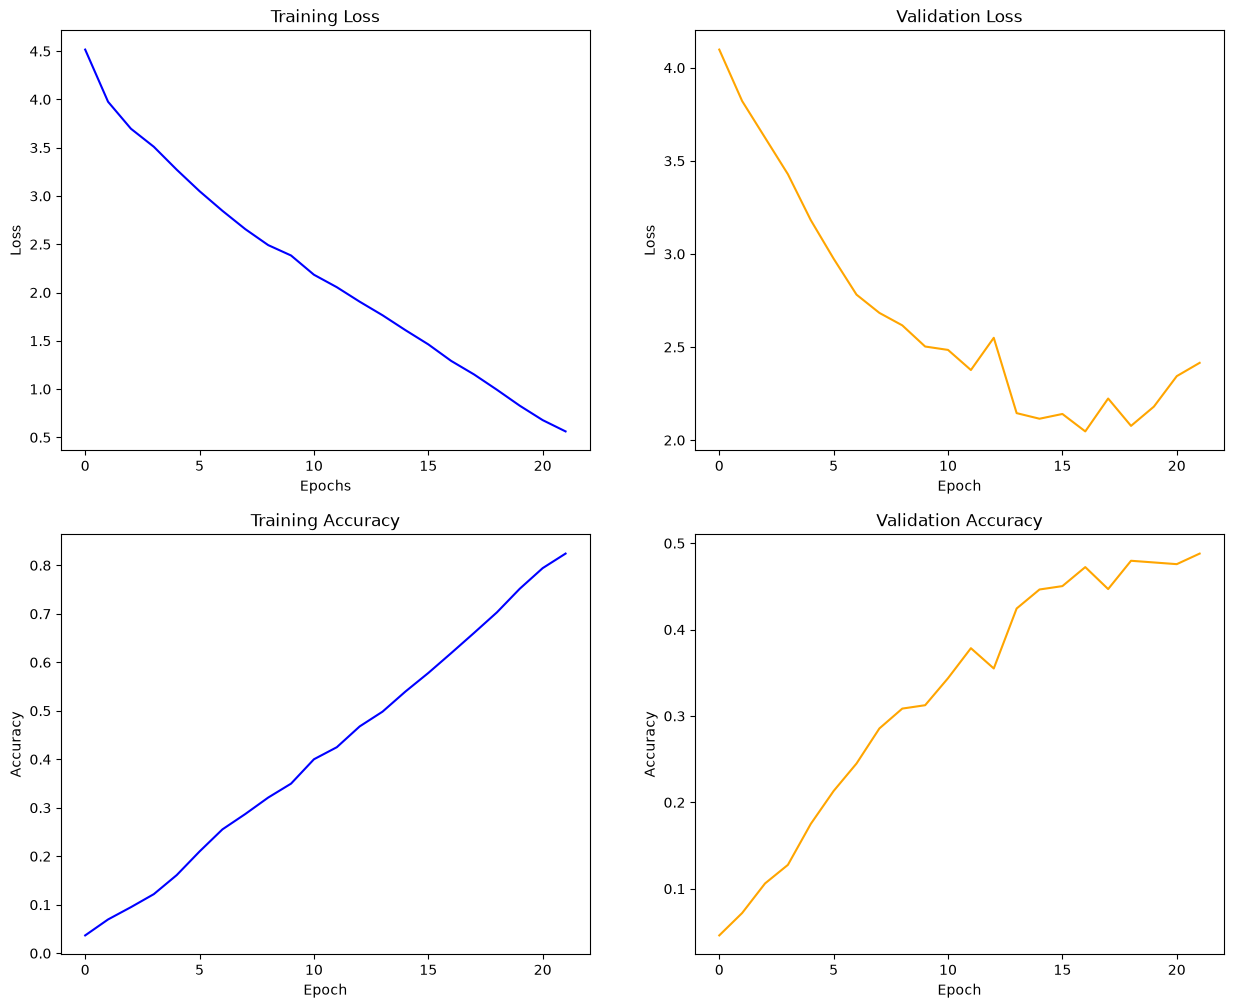

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_loss_list, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_loss_list, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_acc_list, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_acc_list, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()

In [49]:
model.eval()

correct = 0
samples = 0

preds = []
true = []


with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)

        preds.extend(predicted.tolist())
        true.extend(labels.tolist())

accuracy = correct/samples
print(accuracy)

0.49069539666993145
